In [5]:
print("hello peter")

hello peter


In [80]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


In [81]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [82]:
housing = fetch_california_housing()
data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]= housing.target

In [83]:
X = data[['AveRooms']].values
y = data['Price'].values

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [86]:
w=0
b=0
learning_rate = 0.1
epochs = 1000
#store cost value
cost_history=[]

n=len(X_train_scaled)
for i in range(epochs):
    
    y_pred = w* X_train_scaled.flatten()+b
    #compute cost
    cost= (1/(2*n)) * np.sum((y_pred - y_train)**2)
    cost_history.append(cost)
    dw = (1/n) * np.sum((y_pred-y_train)*X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred-y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    if i % 100 == 0:
        cost=(1/(2*n)) * np.sum((y_pred - y_train)**2)
        print(f"Epoch{i}, Cost = {cost:.4f}")
        
        y_pred_gd = w*X_test_scaled.flatten()+b

Epoch0, Cost = 2.8149
Epoch100, Cost = 0.6516
Epoch200, Cost = 0.6516
Epoch300, Cost = 0.6516
Epoch400, Cost = 0.6516
Epoch500, Cost = 0.6516
Epoch600, Cost = 0.6516
Epoch700, Cost = 0.6516
Epoch800, Cost = 0.6516
Epoch900, Cost = 0.6516


In [87]:
print("gradient descent")
print("------------")
print("weight:",w)
print("Bias:",b)
print("MSE:",mean_squared_error(y_test,y_pred_gd))
print("R2 score:",r2_score(y_test, y_pred_gd))

gradient descent
------------
weight: 0.18323881713491486
Bias: 2.0719469373788737
MSE: 1.2923314440807299
R2 score: 0.013795337532284901


In [88]:
X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]
theta= np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train
y_pred_ne = X_test_ne @ theta

In [89]:
print("\n Normal equation")
print("------------")
print("Intercept:",theta[0])
print("slope:",theta[-1])
print("MSE:", mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))



 Normal equation
------------
Intercept: 1.6547622685968417
slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


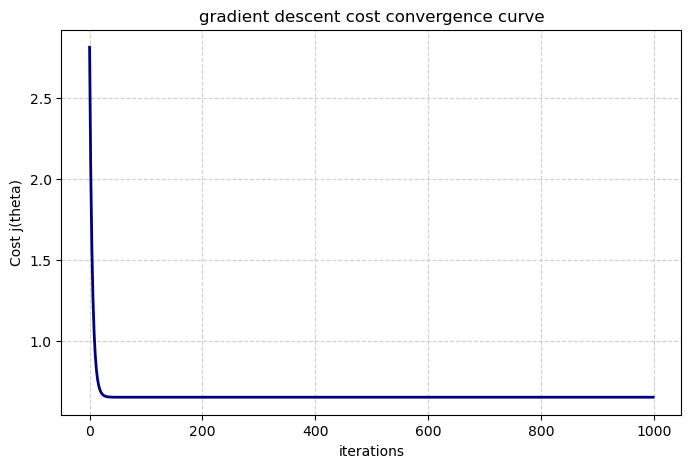

In [90]:
plt.figure(figsize=(8,5))
plt.plot(cost_history, color='navy',linewidth=2)
plt.title('gradient descent cost convergence curve')
plt.xlabel('iterations')
plt.ylabel('Cost j(theta)')
plt.grid(True, linestyle='--', alpha= 0.6)
plt.show()